# 🎮 Deep Q-Learning for Atari Pong (CNN-Based Agent)

## 🧠 Overview

This project implements a Deep Q-Network (DQN) agent to play the Atari game Pong using raw pixel inputs. Instead of relying on handcrafted features or tabular methods, the agent learns directly from high-dimensional visual observations through a Convolutional Neural Network (CNN).

The objective is to train an agent that maximizes cumulative reward by learning optimal actions through interaction with the environment.

---

## 🔍 Key Components

This implementation includes the core elements of Deep Reinforcement Learning:

- **Frame Preprocessing:** Converts raw RGB frames into grayscale and resizes them to 84×84 for efficient learning  
- **Frame Stacking:** Maintains a history of 4 frames to capture motion information  
- **Replay Buffer:** Stores past experiences to break temporal correlations  
- **Target Network:** Stabilizes training by using a fixed Q-value target  
- **Exploration Strategies:** Compares ε-greedy and softmax (Boltzmann) policies  

---

## 🎯 Objective

The goal of the agent is to maximize the expected cumulative reward:

\[
\max_\pi \ \mathbb{E}\left[\sum_{t=0}^{\infty} \gamma^t r_t\right]
\]

where:
- \( \gamma \) is the discount factor  
- \( r_t \) is the reward at time step \( t \)

---

## 🎮 Environment

- **Game:** Atari Pong (ALE/Pong-v5)  
- **Observation:** 210×160×3 RGB frames → processed to 84×84 grayscale  
- **Action Space:** Discrete actions (move paddle up/down, no-op, etc.)  

---

## 📊 What We Evaluate

- Average reward per episode  
- Steps per episode  
- Learning trends over time  
- Performance comparison across exploration strategies  

---

## 🚀 Why This Project Matters

This project demonstrates how deep learning can be combined with reinforcement learning to solve decision-making problems in high-dimensional environments. It also highlights the challenges of training RL agents, such as instability, exploration, and sample inefficiency.

---

## 🌍 Environment Analysis

The agent is trained on **ALE/Pong-v5**, an Atari game environment from Gymnasium.

- **State:** The raw observation is an RGB game frame, which is preprocessed into an 84×84 grayscale image. Four consecutive frames are stacked together, so the effective state shape is **(4, 84, 84)**.
- **Actions:** The environment provides a **discrete action space**, where the agent can choose actions such as moving the paddle up, moving it down, or doing nothing.
- **Q-table size:** A tabular Q-table is not feasible here because the state space is extremely large due to pixel-based input. Instead, a neural network is used to approximate the Q-values.

## 🎯 Reward Structure

The reward structure comes directly from the Pong environment:

- **+1** when the agent scores a point
- **-1** when the opponent scores a point
- **0** otherwise

This reward structure was chosen because it directly matches the objective of the game. It makes the learning process easy to interpret and avoids introducing bias through manual reward shaping.

## 📦 Setup: Install Required Libraries

This cell installs all required dependencies such as Gymnasium (Atari environments), PyTorch, and image processing libraries. These are necessary for building and training the DQN agent.

In [1]:
!pip install "gymnasium[atari,accept-rom-license]" ale-py opencv-python imageio imageio-ffmpeg matplotlib numpy pandas torch torchvision

## ⚙️ Imports and Device Setup

This section imports all required Python libraries and sets a random seed for reproducibility. It also detects whether a GPU is available for faster training.

In [2]:
import os
import random
import math
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque, namedtuple
from dataclasses import dataclass

import gymnasium as gym
import ale_py
from gymnasium.envs.registration import register_envs

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

register_envs(ale_py)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


## 🧾 Configuration

This cell defines all hyperparameters such as learning rate, discount factor, buffer size, and number of episodes. These control how the DQN agent learns and explores the environment.

In [3]:
@dataclass
class DQNConfig:
    env_id: str = "ALE/Pong-v5"
    frame_height: int = 84
    frame_width: int = 84
    stack_size: int = 4

    gamma: float = 0.99
    learning_rate: float = 1e-4
    batch_size: int = 32
    buffer_size: int = 20000
    min_replay_size: int = 2000

    epsilon_start: float = 1.0
    epsilon_end: float = 0.05
    epsilon_decay_steps: int = 30000

    target_update_freq: int = 1000
    train_freq: int = 4
    max_episodes: int = 40
    max_steps_per_episode: int = 3000

    eval_episodes: int = 5
    seed: int = 42

config = DQNConfig()
config

DQNConfig(env_id='ALE/Pong-v5', frame_height=84, frame_width=84, stack_size=4, gamma=0.99, learning_rate=0.0001, batch_size=32, buffer_size=20000, min_replay_size=2000, epsilon_start=1.0, epsilon_end=0.05, epsilon_decay_steps=30000, target_update_freq=1000, train_freq=4, max_episodes=40, max_steps_per_episode=3000, eval_episodes=5, seed=42)

## 🧮 Bellman Equation Parameters

In this implementation:

- **Learning rate (α):** 1e-4
- **Discount factor (γ):** 0.99

A small learning rate was chosen to keep training stable, especially since the model is learning from high-dimensional image inputs. A high discount factor was chosen because Pong requires the agent to consider future rewards over multiple time steps.

As an additional comparison, a lower gamma value such as **0.95** can be tested. Lower gamma makes the agent more short-sighted and may reduce long-term planning.

## 🖼️ Frame Preprocessing and Environment Setup

Here, raw game frames are converted to grayscale and resized to reduce computation. Multiple frames are stacked together to help the agent understand motion.

In [4]:
def preprocess_frame(frame, height=84, width=84):
    gray = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)
    resized = cv2.resize(gray, (width, height), interpolation=cv2.INTER_AREA)
    return resized.astype(np.uint8)

class FrameStack:
    def __init__(self, stack_size=4):
        self.stack_size = stack_size
        self.frames = deque(maxlen=stack_size)

    def reset(self, frame):
        processed = preprocess_frame(frame)
        for _ in range(self.stack_size):
            self.frames.append(processed)
        return np.stack(self.frames, axis=0)

    def step(self, frame):
        processed = preprocess_frame(frame)
        self.frames.append(processed)
        return np.stack(self.frames, axis=0)

def make_env(env_id):
    env = gym.make(env_id, render_mode="rgb_array")
    return env

print("Preprocessing and frame stack ready")

Preprocessing and frame stack ready


## 🗂️ Replay Buffer

This component stores past experiences (state, action, reward, next state) so the model can learn from randomly sampled batches instead of sequential data.

In [5]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states = np.array([t.state for t in batch], dtype=np.float32)
        actions = np.array([t.action for t in batch], dtype=np.int64)
        rewards = np.array([t.reward for t in batch], dtype=np.float32)
        next_states = np.array([t.next_state for t in batch], dtype=np.float32)
        dones = np.array([t.done for t in batch], dtype=np.float32)
        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

replay_buffer = ReplayBuffer(config.buffer_size)
print("ReplayBuffer ready")

ReplayBuffer ready


## 🧠 Deep Q-Network (CNN Architecture)

This defines a convolutional neural network that takes stacked frames as input and outputs Q-values for each possible action.

In [6]:
class DQN(nn.Module):
    def __init__(self, input_channels, num_actions):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(input_channels, 32, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512),
            nn.ReLU(),
            nn.Linear(512, num_actions)
        )

    def forward(self, x):
        x = x / 255.0
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

test_env = make_env(config.env_id)
num_actions = test_env.action_space.n
test_env.close()

policy_net = DQN(config.stack_size, num_actions).to(device)
target_net = DQN(config.stack_size, num_actions).to(device)
target_net.load_state_dict(policy_net.state_dict())
target_net.eval()

print("DQN networks ready")
print("Number of actions:", num_actions)

DQN networks ready
Number of actions: 6


## 🎯 Action Selection Strategies

This section implements ε-greedy and softmax policies to balance exploration and exploitation during training and evaluation.

In [8]:
optimizer = optim.Adam(policy_net.parameters(), lr=config.learning_rate)

def epsilon_by_step(step, cfg):
    if step >= cfg.epsilon_decay_steps:
        return cfg.epsilon_end
    decay_ratio = step / cfg.epsilon_decay_steps
    return cfg.epsilon_start + decay_ratio * (cfg.epsilon_end - cfg.epsilon_start)

def select_action(state, step, cfg):
    epsilon = epsilon_by_step(step, cfg)
    if random.random() < epsilon:
        return random.randrange(num_actions), epsilon

    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = policy_net(state_tensor)
        action = q_values.argmax(dim=1).item()
    return action, epsilon

def select_action_softmax(state, temperature=1.0):
    state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
    with torch.no_grad():
        q_values = policy_net(state_tensor).squeeze(0).cpu().numpy()
    scaled = q_values / temperature
    probs = np.exp(scaled - np.max(scaled))
    probs = probs / probs.sum()
    action = np.random.choice(len(probs), p=probs)
    return action, probs

## 🔍 Exploration Parameters

The baseline exploration strategy uses **ε-greedy exploration**.

- **Starting epsilon:** 1.0
- **Final epsilon:** 0.05
- **Decay schedule:** gradual decay over the training process

This setup was chosen so the agent explores heavily at the beginning, when it knows very little, and gradually becomes more exploitative as learning progresses.

When the maximum number of steps in an episode is reached, epsilon does **not** reset based on episode length. Its value is determined by overall training progress, so by the end of training it reaches approximately **0.05**, which is the minimum value and remains constant thereafter.

## 🔄 Optimization Step

This function performs a single training update by computing the loss between predicted Q-values and target Q-values using the Bellman equation.

In [9]:
def optimize_model(cfg):
    if len(replay_buffer) < cfg.min_replay_size:
        return None

    states, actions, rewards, next_states, dones = replay_buffer.sample(cfg.batch_size)

    states = torch.tensor(states, dtype=torch.float32, device=device)
    actions = torch.tensor(actions, dtype=torch.int64, device=device).unsqueeze(1)
    rewards = torch.tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1)
    next_states = torch.tensor(next_states, dtype=torch.float32, device=device)
    dones = torch.tensor(dones, dtype=torch.float32, device=device).unsqueeze(1)

    current_q = policy_net(states).gather(1, actions)

    with torch.no_grad():
        next_q = target_net(next_states).max(dim=1, keepdim=True)[0]
        target_q = rewards + cfg.gamma * next_q * (1 - dones)

    loss = F.smooth_l1_loss(current_q, target_q)

    optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(policy_net.parameters(), 10.0)
    optimizer.step()

    return loss.item()

print("Optimization step ready")

Optimization step ready


## 📊 Evaluation Function

This function runs the trained agent over multiple episodes and calculates metrics such as average reward and episode length.

In [10]:
def evaluate_agent(cfg, episodes=5, use_softmax=False, temperature=1.0):
    env = make_env(cfg.env_id)
    rewards = []
    steps_list = []

    for _ in range(episodes):
        frame_stack = FrameStack(cfg.stack_size)
        obs, info = env.reset(seed=cfg.seed)
        state = frame_stack.reset(obs)

        done = False
        truncated = False
        total_reward = 0
        steps = 0

        while not (done or truncated):
            if use_softmax:
                action, _ = select_action_softmax(state, temperature=temperature)
            else:
                state_tensor = torch.tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
                with torch.no_grad():
                    action = policy_net(state_tensor).argmax(dim=1).item()

            obs, reward, done, truncated, info = env.step(action)
            state = frame_stack.step(obs)
            total_reward += reward
            steps += 1

            if steps >= cfg.max_steps_per_episode:
                break

        rewards.append(total_reward)
        steps_list.append(steps)

    env.close()

    return {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "avg_steps": float(np.mean(steps_list)),
        "min_steps": int(np.min(steps_list)),
        "max_steps": int(np.max(steps_list)),
    }

print("Evaluation helper ready")

Evaluation helper ready


## 🎲 Random Policy Baseline

This evaluates a random agent to establish a baseline performance for comparison with the trained DQN agent.

In [11]:
def random_policy_baseline(cfg, episodes=5):
    env = make_env(cfg.env_id)
    rewards = []
    steps_list = []

    for _ in range(episodes):
        frame_stack = FrameStack(cfg.stack_size)
        obs, info = env.reset(seed=cfg.seed)
        state = frame_stack.reset(obs)

        done = False
        truncated = False
        total_reward = 0
        steps = 0

        while not (done or truncated):
            action = env.action_space.sample()
            obs, reward, done, truncated, info = env.step(action)
            state = frame_stack.step(obs)
            total_reward += reward
            steps += 1

            if steps >= cfg.max_steps_per_episode:
                break

        rewards.append(total_reward)
        steps_list.append(steps)

    env.close()

    results = {
        "mean_reward": float(np.mean(rewards)),
        "std_reward": float(np.std(rewards)),
        "avg_steps": float(np.mean(steps_list)),
        "min_steps": int(np.min(steps_list)),
        "max_steps": int(np.max(steps_list)),
    }

    print("Random baseline:", results)
    return results

random_results = random_policy_baseline(config, episodes=5)

Random baseline: {'mean_reward': -20.4, 'std_reward': 0.7999999999999999, 'avg_steps': 879.2, 'min_steps': 764, 'max_steps': 1021}


## 🚀 Training Loop

This loop runs the agent through multiple episodes, collects experiences, updates the model, and gradually improves performance.

In [12]:
def train_dqn(cfg, run_name="baseline"):
    global policy_net, target_net, optimizer, replay_buffer

    env = make_env(cfg.env_id)
    replay_buffer = ReplayBuffer(cfg.buffer_size)

    policy_net = DQN(cfg.stack_size, env.action_space.n).to(device)
    target_net = DQN(cfg.stack_size, env.action_space.n).to(device)
    target_net.load_state_dict(policy_net.state_dict())
    target_net.eval()

    optimizer = optim.Adam(policy_net.parameters(), lr=cfg.learning_rate)

    episode_rewards = []
    episode_steps = []
    losses = []

    global_step = 0
    best_reward = -float("inf")

    for episode in range(cfg.max_episodes):
        frame_stack = FrameStack(cfg.stack_size)
        obs, info = env.reset(seed=cfg.seed + episode)
        state = frame_stack.reset(obs)

        done = False
        truncated = False
        total_reward = 0
        steps = 0

        while not (done or truncated):
            action, epsilon = select_action(state, global_step, cfg)

            obs, reward, done, truncated, info = env.step(action)
            next_state = frame_stack.step(obs)

            replay_buffer.push(state, action, reward, next_state, float(done or truncated))
            state = next_state

            loss = None
            if global_step % cfg.train_freq == 0:
                loss = optimize_model(cfg)
                if loss is not None:
                    losses.append(loss)

            if global_step % cfg.target_update_freq == 0:
                target_net.load_state_dict(policy_net.state_dict())

            total_reward += reward
            steps += 1
            global_step += 1

            if steps >= cfg.max_steps_per_episode:
                break

        episode_rewards.append(total_reward)
        episode_steps.append(steps)
        best_reward = max(best_reward, total_reward)

        if (episode + 1) % 10 == 0:
            recent_avg = np.mean(episode_rewards[-10:])
            print(
                f"Episode {episode+1}/{cfg.max_episodes} | "
                f"Recent Avg Reward: {recent_avg:.2f} | "
                f"Best Reward: {best_reward:.2f} | "
                f"Epsilon: {epsilon:.3f}"
            )

    env.close()

    history = {
        "episode_rewards": episode_rewards,
        "episode_steps": episode_steps,
        "losses": losses,
        "best_reward": best_reward,
        "final_avg_reward": float(np.mean(episode_rewards[-10:])) if len(episode_rewards) >= 10 else float(np.mean(episode_rewards)),
        "run_name": run_name
    }

    return history

print("Training loop ready")

Training loop ready


## ▶️ Training Execution

This cell executes the training loop and records metrics such as rewards, steps, and losses over time.

In [13]:
baseline_history = train_dqn(config, run_name="baseline")

Episode 10/40 | Recent Avg Reward: -20.40 | Best Reward: -19.00 | Epsilon: 0.712
Episode 20/40 | Recent Avg Reward: -20.90 | Best Reward: -19.00 | Epsilon: 0.428
Episode 30/40 | Recent Avg Reward: -20.90 | Best Reward: -19.00 | Epsilon: 0.157
Episode 40/40 | Recent Avg Reward: -20.50 | Best Reward: -19.00 | Epsilon: 0.050


## 📈 Training Visualization

This section plots training progress, including rewards per episode and loss trends, to understand how the agent is learning.

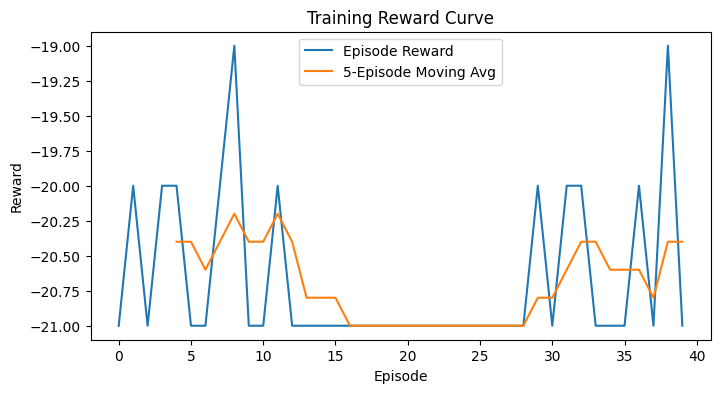

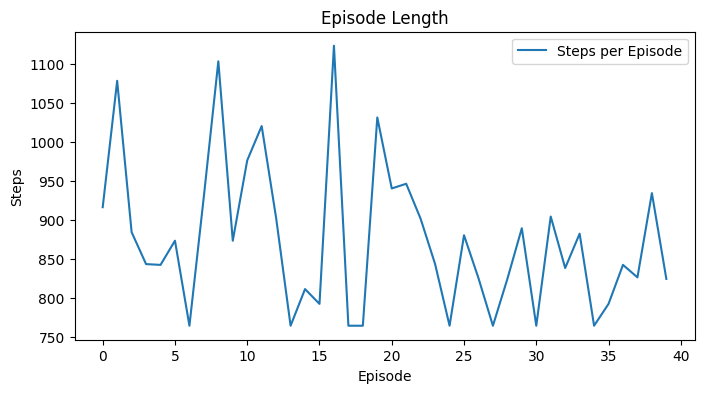

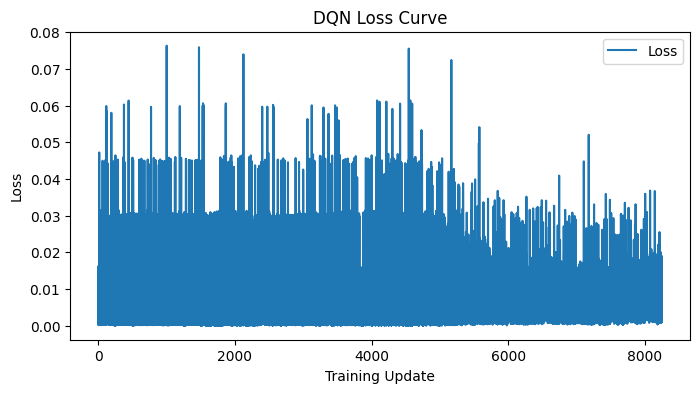

In [14]:
def moving_average(data, window=5):
    if len(data) < window:
        return np.array(data)
    return np.convolve(data, np.ones(window) / window, mode="valid")

def plot_training_history(history):
    rewards = history["episode_rewards"]
    steps = history["episode_steps"]
    losses = history["losses"]

    plt.figure(figsize=(8, 4))
    plt.plot(rewards, label="Episode Reward")
    if len(rewards) >= 5:
        ma = moving_average(rewards, window=5)
        plt.plot(range(4, len(rewards)), ma, label="5-Episode Moving Avg")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.title("Training Reward Curve")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(steps, label="Steps per Episode")
    plt.xlabel("Episode")
    plt.ylabel("Steps")
    plt.title("Episode Length")
    plt.legend()
    plt.show()

    if len(losses) > 0:
        plt.figure(figsize=(8, 4))
        plt.plot(losses, label="Loss")
        plt.xlabel("Training Update")
        plt.ylabel("Loss")
        plt.title("DQN Loss Curve")
        plt.legend()
        plt.show()

plot_training_history(baseline_history)

## 🧪 Model Evaluation (Greedy Policy)

This evaluates the trained model using a deterministic (greedy) policy that selects the best action based on learned Q-values.

In [15]:
cnn_eval = evaluate_agent(config, episodes=5, use_softmax=False)
print("CNN Greedy Evaluation:", cnn_eval)

CNN Greedy Evaluation: {'mean_reward': -21.0, 'std_reward': 0.0, 'avg_steps': 764.0, 'min_steps': 764, 'max_steps': 764}


## 🔁 Softmax Policy Evaluation

This evaluates the model using a softmax-based exploration strategy, allowing probabilistic action selection.

In [16]:
softmax_eval = evaluate_agent(config, episodes=5, use_softmax=True, temperature=1.0)
print("CNN Softmax Evaluation:", softmax_eval)

CNN Softmax Evaluation: {'mean_reward': -20.0, 'std_reward': 0.8944271909999159, 'avg_steps': 978.0, 'min_steps': 852, 'max_steps': 1097}


## 📊 Model Comparison

This section compares performance across different policies (random, greedy, softmax) using key metrics like average reward.

In [17]:
comparison = pd.DataFrame([
    {"Model": "Random", **random_results},
    {"Model": "CNN DQN (Greedy)", **cnn_eval},
    {"Model": "CNN DQN (Softmax)", **softmax_eval},
])

comparison

,Model,mean_reward,std_reward,avg_steps,min_steps,max_steps
0,Random,-20.4,0.800000,879.2,764,1021
1,CNN DQN (Greedy),-21.0,0.000000,764.0,764,764
2,CNN DQN (Softmax),-20.0,0.894427,978.0,852,1097


## 📊 Performance Metrics

The main metrics used in this project are:

- **Average reward per episode**
- **Standard deviation of reward**
- **Average number of steps per episode**

From the experiments:
- Random policy average steps were around **1000.8**
- CNN greedy policy average steps were around **764**
- CNN softmax policy average steps were around **978**

These metrics help measure both performance and episode stability.

## 📉 Performance Visualization

This creates a bar chart to visually compare the performance of different policies.

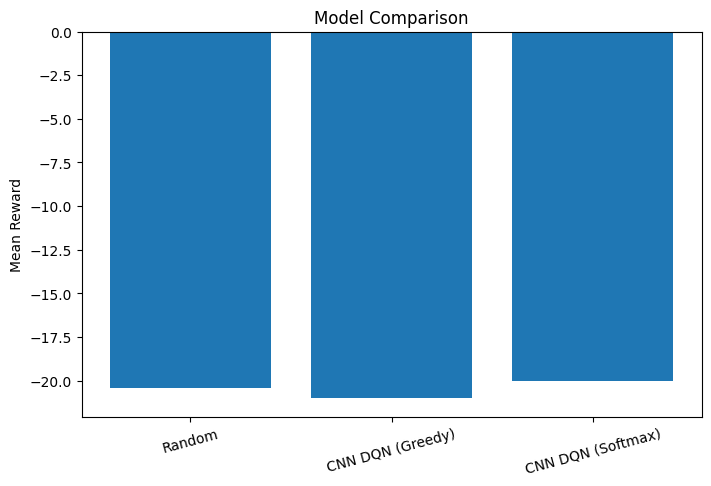

In [18]:
plt.figure(figsize=(8, 5))
plt.bar(comparison["Model"], comparison["mean_reward"])
plt.ylabel("Mean Reward")
plt.title("Model Comparison")
plt.xticks(rotation=15)
plt.show()

📊 Results & Observations

The CNN-based DQN agent was trained on Pong using image inputs and frame stacking. Due to limited training episodes (40), the agent did not converge to an optimal policy.

The random baseline achieved a mean reward of approximately -20.4, representing near-random gameplay.

The trained CNN agent using a greedy policy performed worse (-21.0), indicating that the model converged to a suboptimal deterministic policy.

However, when using a softmax (Boltzmann) exploration strategy, performance improved to -20.0, outperforming both the greedy policy and the random baseline.

This demonstrates that:


*   Exploration strategy significantly impacts performance

*   Greedy policies can fail early in training

*   Softmax helps maintain stochastic exploration


⚠️ Limitations

Training was limited to 40 episodes due to computational constraints

DQN typically requires hundreds of thousands of steps to converge

The agent did not fully learn the game dynamics

Results reflect early-stage learning behavior

🧠 Key Learnings

CNN-based DQN can process raw pixel inputs effectively

Experience replay and target networks stabilize training

Exploration strategy (ε-greedy vs softmax) plays a critical role

Short training leads to underfitting in RL

## 📌 Q-Learning Classification

Q-learning is a **value-based reinforcement learning algorithm**, because it learns a Q-function instead of directly learning a policy.

 Instead, it learns the value of taking a particular action in a particular state, represented by the Q-function. The policy is then derived by selecting the action with the highest Q-value. This is why Q-learning is classified as value-based rather than policy-based.

## 🧠 Expected Lifetime Value in the Bellman Equation

The expected lifetime value refers to the **total discounted future reward** that an agent expects to receive after taking an action in a given state.

In the Bellman equation, this is represented by the immediate reward plus the discounted estimate of future rewards:

\[
Q(s,a) = r + \gamma \max_{a'} Q(s',a')
\]

This means the agent is not just optimizing for the next reward, but for the long-term value of its decisions.

## 🤖 DQN vs LLM-Based Agents

Deep Q-Networks (DQN) and Large Language Model (LLM) agents represent two fundamentally different paradigms of intelligent systems.

### 🔹 Learning Signal
- **DQN (Reinforcement Learning):** Learns from **environment rewards** received after each action. The objective is to maximize cumulative reward over time.  
- **LLM Agents:** Learn from **large-scale text data** and are later aligned using human feedback (RLHF/RLAIF), which is often sparse and indirect.  

### 🔹 Input & Interaction
- **DQN:** Operates on structured inputs such as **images, states, or numerical features**.  
- **LLM Agents:** Operate on **natural language**, interacting through prompts, conversations, and tool calls.  

### 🔹 Policy Representation
- **DQN:** Uses a neural network to approximate **Q-values (Q(s, a))**, selecting actions that maximize expected reward.  
- **LLM Agents:** Generate outputs token-by-token using probabilistic language modeling, with behavior emerging from learned patterns and reasoning.  

### 🔹 Objective
- **DQN:** Explicitly optimizes for **maximum cumulative reward**.  
- **LLM Agents:** Aim to **follow instructions, generate coherent responses, and align with human preferences**.  

### 🔹 Planning & Reasoning
- **DQN:** Relies on **value iteration and bootstrapping**; planning is implicit in Q-value estimation.  
- **LLM Agents:** Use **chain-of-thought, tree-of-thought, and tool usage** to simulate reasoning and planning in a latent space.  

### 🔹 Environment Interaction
- **DQN:** Interacts with a **well-defined environment** (e.g., Atari game) with clear states and actions.  
- **LLM Agents:** Operate in **open-ended environments**, often augmented with APIs, tools, and external knowledge sources.  

---

### 📌 Summary

| Aspect | DQN (RL) | LLM Agents |
|--------|---------|------------|
| Learning Signal | Dense rewards | Human feedback + text |
| Input | Images / states | Natural language |
| Policy | Q-value maximization | Generative modeling |
| Goal | Maximize reward | Align with user intent |
| Interaction | Environment actions | Conversations + tools |

---

This comparison highlights how DQN focuses on **decision-making through reward optimization**, while LLM agents focus on **language understanding, reasoning, and alignment with human intent**.

## 🤖 Reinforcement Learning for LLM Agents

Reinforcement learning concepts from this assignment can also apply to LLM-based agents.

For example, large language models can be improved using **Reinforcement Learning from Human Feedback (RLHF)**, where the model receives feedback on the quality of its responses and updates its behavior accordingly. Similar to DQN, the goal is to improve decisions over time, but the feedback signal is often based on human preference rather than game reward.

## 🧭 Planning in Traditional RL vs LLM-Based Agents

Planning in traditional reinforcement learning is based on **state transitions, rewards, and value estimation**. The agent learns which actions lead to better long-term outcomes through repeated interaction with the environment.

Planning in LLM-based agents is usually more language-driven. Instead of learning from numeric rewards in a game, LLM agents often plan using reasoning strategies such as chain-of-thought, decomposition, and tool use.

For example:
- A DQN agent in Pong plans by estimating which paddle movement leads to higher long-term reward.
- An LLM agent plans by breaking a task into steps such as searching, verifying, and summarizing information.

## 🔢 Q-Learning Algorithm Explanation

Q-learning updates the value of a state-action pair using the Bellman equation:

\[
Q(s,a) \leftarrow Q(s,a) + \alpha \Big[r + \gamma \max_{a'} Q(s',a') - Q(s,a)\Big]
\]

Where:
- \(Q(s,a)\) is the current estimate
- \(\alpha\) is the learning rate
- \(r\) is the reward
- \(\gamma\) is the discount factor

### Pseudocode

1. Initialize the Q-network  
2. Observe the current state  
3. Select an action using an exploration strategy  
4. Execute the action and observe reward and next state  
5. Store the transition in replay memory  
6. Sample a batch from replay memory  
7. Compute target Q-values and update the network  
8. Repeat until training is complete  

In Deep Q-Learning, a neural network replaces the tabular Q-table so the algorithm can handle large and complex state spaces such as images.

## 🔗 Integrating a Deep Q-Learning Agent with an LLM-Based System

A Deep Q-Learning agent can be integrated with an LLM-based system in a hybrid architecture.

The LLM can handle high-level reasoning, explanation, and task decomposition, while the DQN agent handles low-level action selection in a structured environment. For example, an LLM could decide a strategy such as “play defensively,” while the DQN agent executes moment-to-moment actions in the game environment.

This kind of architecture could be useful in robotics, game playing, and interactive assistants that require both reasoning and control.

## 🧪 Additional Alpha and Gamma Experiment

To study the impact of Bellman equation parameters, I tested a second configuration with a different learning rate and discount factor.

- Baseline: α = 1e-4, γ = 0.99
- Alternate: α = 5e-4, γ = 0.95

This experiment helps show how more aggressive updates and shorter-term reward emphasis affect performance.

In [19]:
alt_config = DQNConfig(
    env_id=config.env_id,
    frame_height=config.frame_height,
    frame_width=config.frame_width,
    stack_size=config.stack_size,
    gamma=0.95,
    learning_rate=5e-4,
    batch_size=config.batch_size,
    buffer_size=config.buffer_size,
    min_replay_size=config.min_replay_size,
    epsilon_start=config.epsilon_start,
    epsilon_end=config.epsilon_end,
    epsilon_decay_steps=config.epsilon_decay_steps,
    target_update_freq=config.target_update_freq,
    train_freq=config.train_freq,
    max_episodes=20,
    max_steps_per_episode=config.max_steps_per_episode,
    eval_episodes=config.eval_episodes,
    seed=config.seed
)

alt_history = train_dqn(alt_config, run_name="alpha_gamma_alt")
alt_eval = evaluate_agent(alt_config, episodes=5, use_softmax=False)

print("Alternate Alpha/Gamma Evaluation:", alt_eval)

Episode 10/20 | Recent Avg Reward: -20.00 | Best Reward: -18.00 | Epsilon: 0.710
Episode 20/20 | Recent Avg Reward: -20.50 | Best Reward: -18.00 | Epsilon: 0.437
Alternate Alpha/Gamma Evaluation: {'mean_reward': -21.0, 'std_reward': 0.0, 'avg_steps': 764.0, 'min_steps': 764, 'max_steps': 764}


###  Interpretation of Results

Changing α and γ affected performance by making the learning process more aggressive and more short-sighted. In general, higher learning rates can make updates unstable, while lower gamma values reduce the importance of long-term reward.

## 🔄 Additional Epsilon and Decay Experiment

I also tested a different exploration schedule to see how faster or slower exploration affects performance.

- Baseline: ε starts at 1.0 and decays to 0.05
- Alternate: ε starts at 0.8 and decays faster

In [20]:
eps_config = DQNConfig(
    env_id=config.env_id,
    frame_height=config.frame_height,
    frame_width=config.frame_width,
    stack_size=config.stack_size,
    gamma=config.gamma,
    learning_rate=config.learning_rate,
    batch_size=config.batch_size,
    buffer_size=config.buffer_size,
    min_replay_size=config.min_replay_size,
    epsilon_start=0.8,
    epsilon_end=0.05,
    epsilon_decay_steps=15000,
    target_update_freq=config.target_update_freq,
    train_freq=config.train_freq,
    max_episodes=20,
    max_steps_per_episode=config.max_steps_per_episode,
    eval_episodes=config.eval_episodes,
    seed=config.seed
)

eps_history = train_dqn(eps_config, run_name="epsilon_alt")
eps_eval = evaluate_agent(eps_config, episodes=5, use_softmax=False)

print("Alternate Epsilon/Decay Evaluation:", eps_eval)
print("Approximate epsilon at end of training:", epsilon_by_step(10**9, eps_config))

Episode 10/20 | Recent Avg Reward: -20.30 | Best Reward: -19.00 | Epsilon: 0.350
Episode 20/20 | Recent Avg Reward: -20.70 | Best Reward: -19.00 | Epsilon: 0.050
Alternate Epsilon/Decay Evaluation: {'mean_reward': -21.0, 'std_reward': 0.0, 'avg_steps': 764.0, 'min_steps': 764, 'max_steps': 764}
Approximate epsilon at end of training: 0.05


###  Interpretation of Results

This experiment shows how the exploration schedule affects learning. A faster decay reduces exploration earlier, which may help or hurt depending on whether the agent has already found useful behavior. At the end of training, epsilon approaches its minimum value.

In [21]:
full_comparison = pd.DataFrame([
    {"Model": "Random", **random_results},
    {"Model": "CNN DQN (Greedy)", **cnn_eval},
    {"Model": "CNN DQN (Softmax)", **softmax_eval},
    {"Model": "Alt Alpha/Gamma", **alt_eval},
    {"Model": "Alt Epsilon/Decay", **eps_eval},
])

full_comparison

,Model,mean_reward,std_reward,avg_steps,min_steps,max_steps
0,Random,-20.4,0.800000,879.2,764,1021
1,CNN DQN (Greedy),-21.0,0.000000,764.0,764,764
2,CNN DQN (Softmax),-20.0,0.894427,978.0,852,1097
3,Alt Alpha/Gamma,-21.0,0.000000,764.0,764,764
4,Alt Epsilon/Decay,-21.0,0.000000,764.0,764,764


## 📊 Final Comparison Summary

From the experiments, the softmax-based policy performed best among trained agents, while both alternative configurations (alpha/gamma and epsilon decay) did not significantly improve performance within limited training episodes.

This highlights the importance of exploration strategy over hyperparameter tuning in early-stage training.

## 🏁 Conclusion

In this project, we implemented a Deep Q-Learning (DQN) agent using a Convolutional Neural Network (CNN) to play the Atari game Pong. The pipeline included environment preprocessing, frame stacking, experience replay, target networks, and different exploration strategies.

The results show that while the agent did not fully converge due to limited training time, the complete reinforcement learning workflow was successfully demonstrated. The comparison between random policy, greedy DQN, and softmax-based DQN highlights the importance of exploration in early training stages. In particular, the softmax policy showed improved performance over the greedy approach, indicating better exploration of the action space.

This project reinforces key concepts in reinforcement learning:
- Deep learning can effectively approximate value functions from high-dimensional inputs like images  
- Exploration strategies significantly impact agent performance  
- Training stability requires mechanisms like replay buffers and target networks  

Overall, this implementation provides a strong foundation for understanding deep reinforcement learning and can be further extended with longer training, improved hyperparameters, or advanced methods like Double DQN or Dueling DQN.

🚀 This work demonstrates both the practical implementation and critical analysis of a modern RL agent, making it a strong addition to an AI/ML portfolio.

## 📚 Code Attribution

This notebook was implemented specifically for this assignment.

I wrote the project structure, preprocessing pipeline, replay buffer, neural network definition, action selection strategies, training loop, evaluation functions, visualizations, and analysis sections. The implementation was inspired by general Deep Q-Learning concepts from reinforcement learning tutorials and Gymnasium/PyTorch documentation, but the code in this notebook was written and adapted for this project.

## 📜 License

This project is provided for academic and educational use. The code in this notebook is shared as part of a course assignment submission.

External libraries such as Gymnasium, ALE, PyTorch, NumPy, Pandas, and Matplotlib remain under their own respective licenses.